In [ ]:
import pandas as pd

In [ ]:
from google.colab import files

In [ ]:
# Step 1: Upload the CSV file
uploaded = files.upload()

Saving marketing_campaign_csv.csv to marketing_campaign_csv.csv


In [ ]:
# Load the uploaded Excel file
file_path = 'marketing_campaign_csv.csv'
df = pd.read_csv(file_path)

In [ ]:
# Step 3 (optional): Check the first few rows
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,01/01/2021,506,1922,6,Health & Wellness
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,01/02/2021,116,7523,7,Fashionistas
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,01/03/2021,584,7698,1,Outdoor Adventurers
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,01/04/2021,217,1820,7,Health & Wellness
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,01/05/2021,379,4201,3,Health & Wellness


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200005 entries, 0 to 200004
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200005 non-null  int64  
 1   Company           200005 non-null  object 
 2   Campaign_Type     200005 non-null  object 
 3   Target_Audience   200005 non-null  object 
 4   Duration          200005 non-null  object 
 5   Channel_Used      200005 non-null  object 
 6   Conversion_Rate   200005 non-null  float64
 7   Acquisition_Cost  200005 non-null  object 
 8   ROI               200005 non-null  float64
 9   Location          200005 non-null  object 
 10  Date              200005 non-null  object 
 11  Clicks            200005 non-null  int64  
 12  Impressions       200005 non-null  int64  
 13  Engagement_Score  200005 non-null  int64  
 14  Customer_Segment  200005 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 22.9+ MB


In [ ]:
df.describe(include='all')

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
count,200005.000000,200005,200005,200005,200005,200005,200005.000000,200005,200005.000000,200005,200005,200005.000000,200005.000000,200005.000000,200005
unique,NaN,5,5,5,4,6,NaN,15001,NaN,5,365,NaN,NaN,NaN,5
top,NaN,TechCorp,Influencer,Men 18-24,30 days,Email,NaN,"$16,578.00",NaN,Miami,12/10/2021,NaN,NaN,NaN,Foodies
freq,NaN,40238,40170,40259,50257,33599,NaN,32,NaN,40269,549,NaN,NaN,NaN,40210
mean,100003.000000,NaN,NaN,NaN,NaN,NaN,0.080069,NaN,5.002416,NaN,NaN,549.774591,5507.307107,5.494673,NaN
std,57736.614632,NaN,NaN,NaN,NaN,NaN,0.040602,NaN,1.734485,NaN,NaN,260.019354,2596.863794,2.872593,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,0.010000,NaN,2.000000,NaN,NaN,100.000000,1000.000000,1.000000,NaN
25%,50002.000000,NaN,NaN,NaN,NaN,NaN,0.050000,NaN,3.500000,NaN,NaN,325.000000,3266.000000,3.000000,NaN
50%,100003.000000,NaN,NaN,NaN,NaN,NaN,0.080000,NaN,5.010000,NaN,NaN,550.000000,5518.000000,5.000000,NaN
75%,150004.000000,NaN,NaN,NaN,NaN,NaN,0.120000,NaN,6.510000,NaN,NaN,775.000000,7753.000000,8.000000,NaN


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Clean up 'Date' column for temporal analysis
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y') # Specify the correct format

In [ ]:
# Compute CTR and CPC
df['CTR'] = df['Clicks'] / df['Impressions']

# Convert 'Acquisition_Cost' to numeric before calculating CPC
df['Acquisition_Cost'] = pd.to_numeric(df['Acquisition_Cost'].str.replace(',', '').str.replace('$', ''), errors='coerce')
df['CPC'] = df['Acquisition_Cost'] / df['Clicks']

In [ ]:
# Drop rows with potential division by zero
df.replace([float('inf'), -float('inf')], pd.NA, inplace=True)
df.dropna(subset=['CTR', 'CPC'], inplace=True)

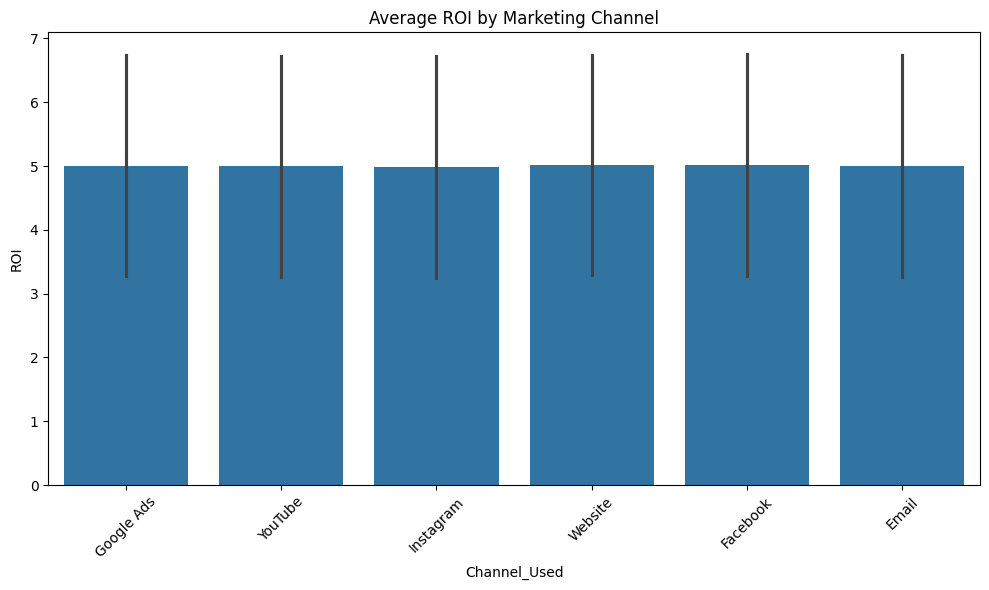

In [ ]:
# Prepare visualization 1:  Average ROI by Marketing Channel
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Channel_Used', y='ROI', estimator='mean', errorbar='sd')
plt.title('Average ROI by Marketing Channel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

<ipython-input-17-6db7cdc9a9c3>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df, x='Channel_Used', y='ROI', estimator=np.mean, ci='sd')


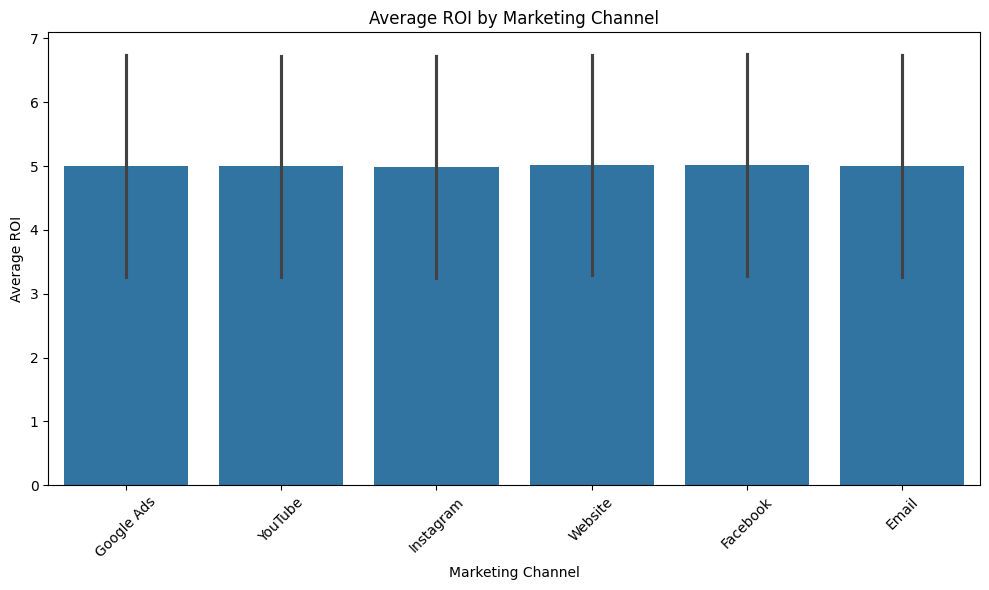

In [ ]:
# Correcting the barplot visualization using ci='sd' instead of 'errorbar'
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Channel_Used', y='ROI', estimator=np.mean, ci='sd')
plt.title('Average ROI by Marketing Channel')
plt.xlabel('Marketing Channel')
plt.ylabel('Average ROI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-18-e3c0766d3b26>:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


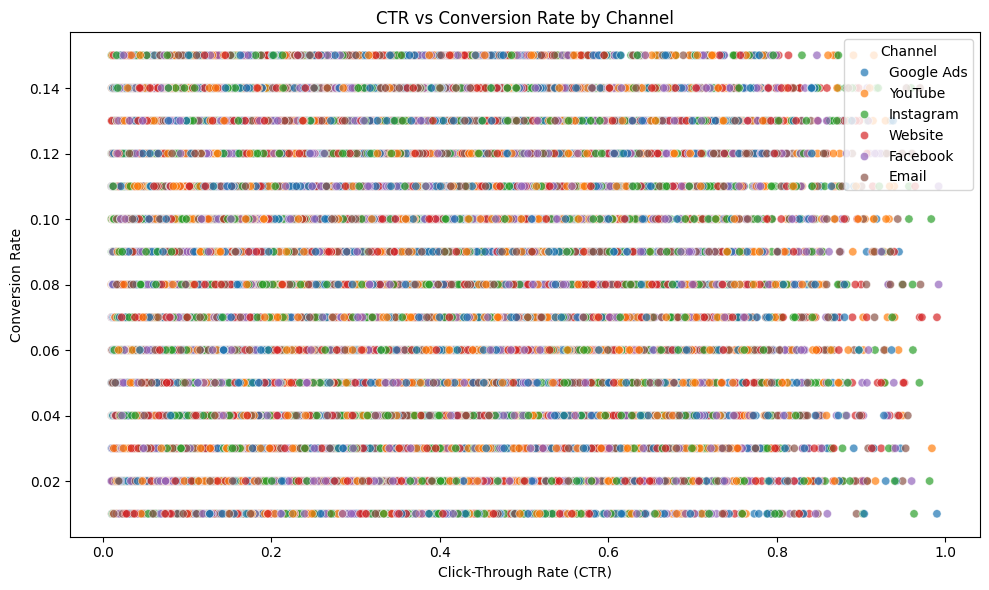

In [ ]:
# Visualization 2: Scatter plot of CTR vs Conversion Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CTR', y='Conversion_Rate', hue='Channel_Used', alpha=0.7)
plt.title('CTR vs Conversion Rate by Channel')
plt.xlabel('Click-Through Rate (CTR)')
plt.ylabel('Conversion Rate')
plt.legend(title='Channel')
plt.tight_layout()
plt.show()

In [ ]:
# Prepare data for line chart: Monthly Clicks Trend
df['Month'] = df['Date'].dt.to_period('M')
monthly_clicks = df.groupby('Month')['Clicks'].sum().reset_index()
monthly_clicks['Month'] = monthly_clicks['Month'].astype(str)

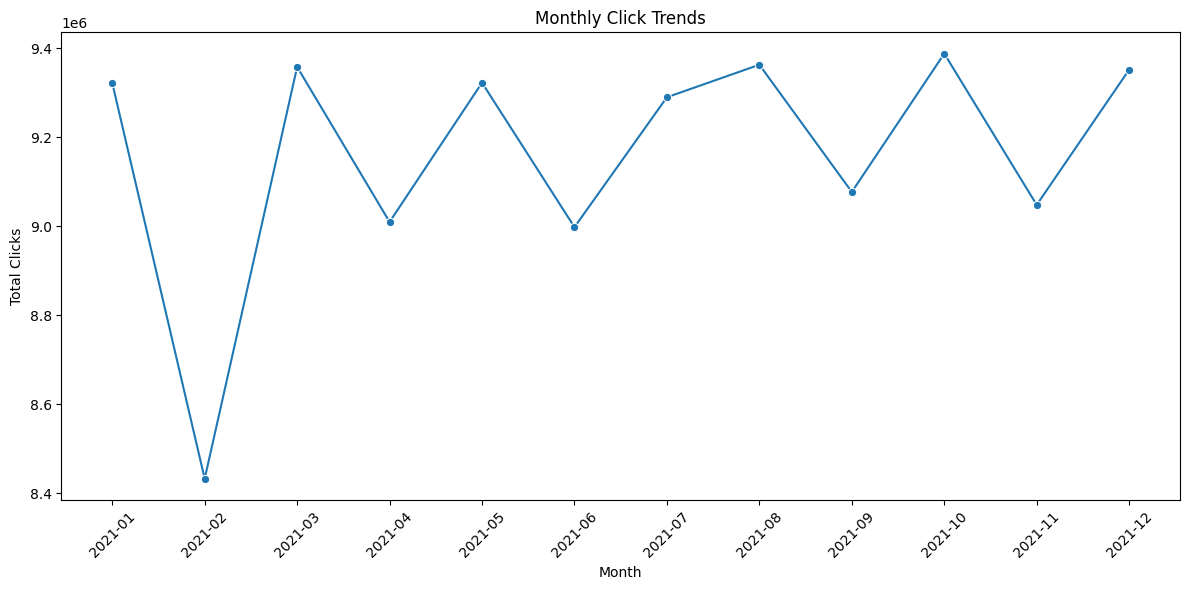

In [ ]:
# Visualization 3: Line Chart - Monthly Clicks Trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_clicks, x='Month', y='Clicks', marker='o')
plt.title('Monthly Click Trends')
plt.xlabel('Month')
plt.ylabel('Total Clicks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Prepare pivot table for heatmap
heatmap_data = df.pivot_table(values='ROI', index='Location', columns='Campaign_Type', aggfunc='mean')

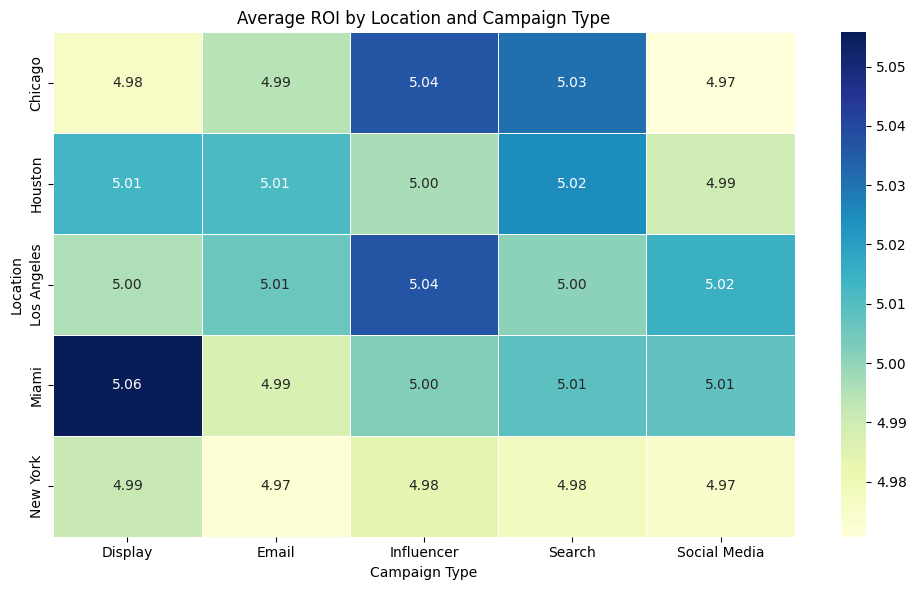

In [ ]:
# Visualization 4: Heatmap - Average ROI by Location and Campaign Type
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title('Average ROI by Location and Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

In [ ]:
# Prepare a clean version of the DataFrame with calculated metrics for use in the Jupyter Notebook
eda_df = df.copy()
eda_df = eda_df[['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Channel_Used',
                 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Clicks',
                 'Impressions', 'CTR', 'CPC', 'Engagement_Score', 'Customer_Segment', 'Date']]

In [ ]:
# Save this to a CSV so it can be easily imported into a Jupyter Notebook
output_path = "/content/eda_marketing_clean.csv"
eda_df.to_csv(output_path, index=False)

output_path

'/content/eda_marketing_clean.csv'